In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('alzheimers_disease_data.csv')
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,0,0,1,1,0,0,142,72,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,0,0,0,0,0,0,115,64,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,1,0,0,0,0,0,99,116,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,0,0,0,0,0,0,118,115,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,0,0,0,0,0,0,94,117,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [13]:
from sklearn.preprocessing import StandardScaler

columns = ['Age', 'BMI', 'SystolicBP', 'CholesterolTotal', 'MMSE']

scaler = StandardScaler()
scaled = scaler.fit_transform(df[columns])

df_scaled = pd.DataFrame(scaled, columns=columns)

print(df_scaled.describe().loc[['mean', 'std']].round(2))

      Age  BMI  SystolicBP  CholesterolTotal  MMSE
mean  0.0  0.0        -0.0              -0.0  -0.0
std   1.0  1.0         1.0               1.0   1.0


In [18]:
age_z = (df['Age'] - df['Age'].mean()) / df['Age'].std()
print('min age:',round(age_z.min(), 2))
print('max age:',round(age_z.max(), 2))

min age: -1.66
max age: 1.68


In [51]:
from sklearn.preprocessing import MinMaxScaler

kolonlar = ['Age', 'BMI', 'SystolicBP', 'CholesterolTotal', 'MMSE']

mm = MinMaxScaler()
df_norm = pd.DataFrame(mm.fit_transform(df[columns]), columns=columns)

print(df_norm.describe().loc[['min', 'mean', 'max']].round(3))

        Age    BMI  SystolicBP  CholesterolTotal   MMSE
min   0.000  0.000       0.000             0.000  0.000
mean  0.497  0.506       0.497             0.501  0.492
max   1.000  1.000       1.000             1.000  1.000


In [25]:
print('Null values:', df.isnull().sum().sum())
print('Repetetive values :', df.duplicated().sum())

Null values: 0
Repetetive values : 0


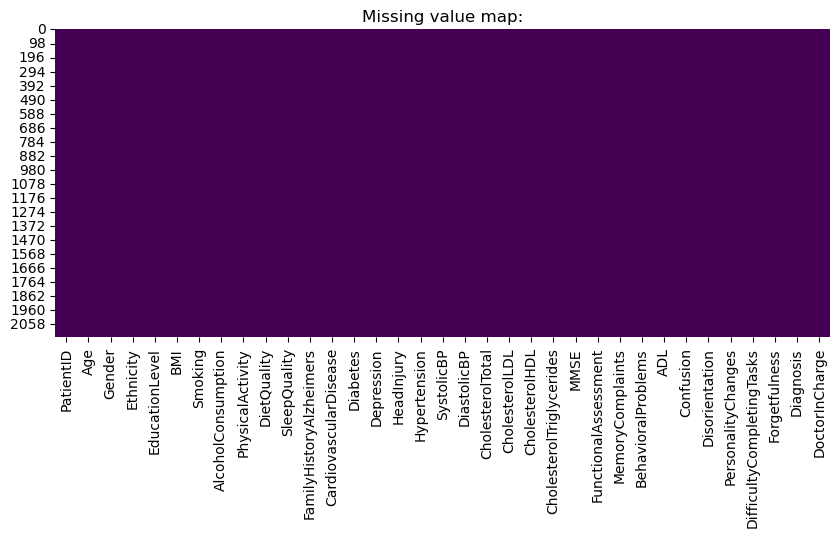

In [26]:
plt.figure(figsize=(10,4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing value map:')
plt.show()

In [29]:
df_clean = df.drop(columns=['PatientID', 'DoctorInCharge']) 
df_clean= pd.get_dummies(df_clean, columns=['Ethnicity'], prefix='Ethnicity', dtype=int)

print(df_clean.shape)

(2149, 36)


In [32]:
continuous = ['Age','BMI','AlcoholConsumption','PhysicalActivity','DietQuality','SleepQuality',
           'SystolicBP','DiastolicBP','CholesterolTotal','CholesterolLDL','CholesterolHDL',
           'CholesterolTriglycerides','MMSE','FunctionalAssessment','ADL']

print('%-26s %8s  %8s  %8s' % ('Column', 'Aykırı', 'Min', 'Max'))
print('-' * 56)
for column in continuous:
    q1, q3 = df[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    base, roof = q1 - 1.5*iqr, q3 + 1.5*iqr
    n = ((df[column] < base) | (df[column] > roof)).sum()
    print('%-26s %8d  %8.1f  %8.1f' % (column, n, df[column].min(), df[column].max()))

Column                       Aykırı       Min       Max
--------------------------------------------------------
Age                               0      60.0      90.0
BMI                               0      15.0      40.0
AlcoholConsumption                0       0.0      20.0
PhysicalActivity                  0       0.0      10.0
DietQuality                       0       0.0      10.0
SleepQuality                      0       4.0      10.0
SystolicBP                        0      90.0     179.0
DiastolicBP                       0      60.0     119.0
CholesterolTotal                  0     150.1     300.0
CholesterolLDL                    0      50.2     200.0
CholesterolHDL                    0      20.0     100.0
CholesterolTriglycerides          0      50.4     399.9
MMSE                              0       0.0      30.0
FunctionalAssessment              0       0.0      10.0
ADL                               0       0.0      10.0


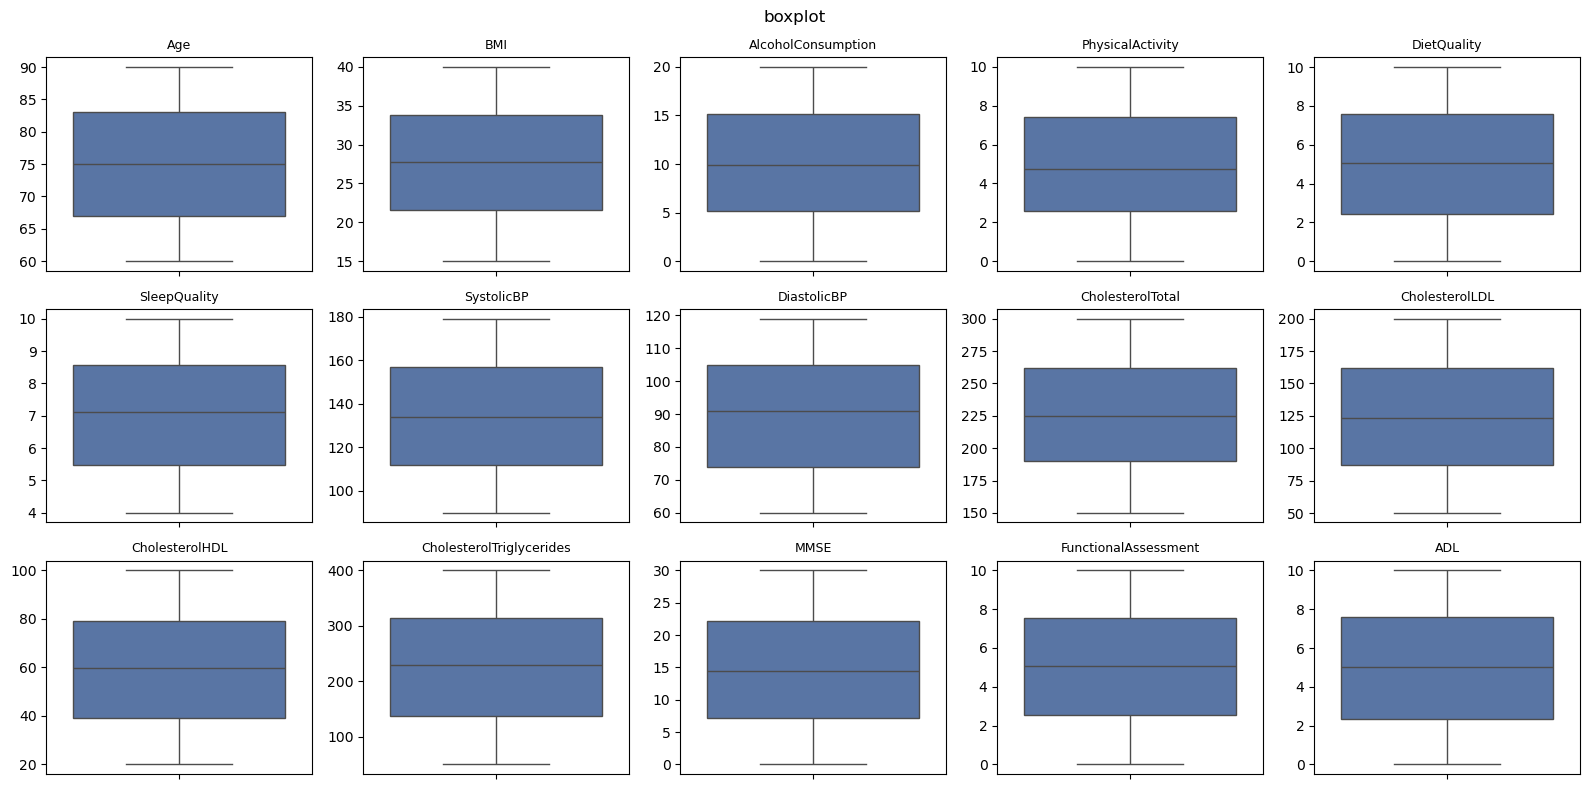

In [34]:
fig, axes = plt.subplots(3, 5, figsize=(16, 8))
for ax, column in zip(axes.flat, continuous):
    sns.boxplot(y=df[column], ax=ax, color='#4C72B0')
    ax.set_title(column, fontsize=9)
    ax.set_ylabel('')
plt.suptitle('boxplot')
plt.tight_layout()
plt.show()

In [35]:
df.info()          
df.describe().T   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

,count,mean,std,min,25%,50%,75%,max
PatientID,2149.0,5825.000000,620.507185,4751.000000,5288.000000,5825.000000,6362.000000,6899.000000
Age,2149.0,74.908795,8.990221,60.000000,67.000000,75.000000,83.000000,90.000000
Gender,2149.0,0.506282,0.500077,0.000000,0.000000,1.000000,1.000000,1.000000
Ethnicity,2149.0,0.697534,0.996128,0.000000,0.000000,0.000000,1.000000,3.000000
EducationLevel,2149.0,1.286645,0.904527,0.000000,1.000000,1.000000,2.000000,3.000000
BMI,2149.0,27.655697,7.217438,15.008851,21.611408,27.823924,33.869778,39.992767
Smoking,2149.0,0.288506,0.453173,0.000000,0.000000,0.000000,1.000000,1.000000
AlcoholConsumption,2149.0,10.039442,5.757910,0.002003,5.139810,9.934412,15.157931,19.989293
PhysicalActivity,2149.0,4.920202,2.857191,0.003616,2.570626,4.766424,7.427899,9.987429
DietQuality,2149.0,4.993138,2.909055,0.009385,2.458455,5.076087,7.558625,9.998346


Diagnosis
0    1389
1     760
Name: count, dtype: int64
Diagnosis
0    0.646
1    0.354
Name: proportion, dtype: float64


C:\Users\ddoga\AppData\Local\Temp\ipykernel_23256\4132946267.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Diagnosis', data=df, palette=['#4C72B0','#C44E52'])


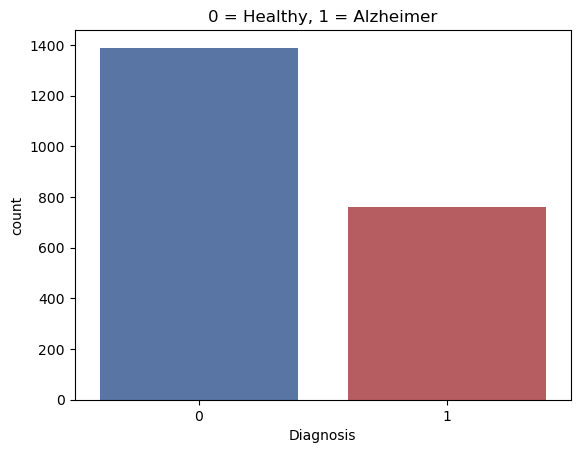

In [36]:
print(df['Diagnosis'].value_counts())
print(df['Diagnosis'].value_counts(normalize=True).round(3))

sns.countplot(x='Diagnosis', data=df, palette=['#4C72B0','#C44E52'])
plt.title('0 = Healthy, 1 = Alzheimer')
plt.show()

In [38]:
df_clean.shape

(2149, 36)

In [39]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=['Diagnosis']) 
y = df_clean['Diagnosis']                  

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     
    stratify=y,         
    random_state=42     
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('\nTrain:', dict(y_train.value_counts(normalize=True).round(3)))
print('Test: ', dict(y_test.value_counts(normalize=True).round(3)))

X_train: (1719, 35)
X_test : (430, 35)

Train: {0: np.float64(0.646), 1: np.float64(0.354)}
Test:  {0: np.float64(0.647), 1: np.float64(0.353)}


In [40]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [41]:
models = {
    'Logistic Regression': (
        Pipeline([('scaler', StandardScaler()),
                  ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
        {'clf__C': [0.01, 0.1, 1, 10, 100]}
    ),
    'KNN': (
        Pipeline([('scaler', StandardScaler()),
                  ('clf', KNeighborsClassifier())]),
        {'clf__n_neighbors': [3, 5, 7, 9, 11, 15],
         'clf__weights': ['uniform', 'distance']}
    ),
    'Decision Tree': (
        Pipeline([('clf', DecisionTreeClassifier(random_state=42))]),
        {'clf__max_depth': [3, 5, 7, 10, None],
         'clf__min_samples_leaf': [1, 5, 10]}
    ),
    'Random Forest': (
        Pipeline([('clf', RandomForestClassifier(random_state=42))]),
        {'clf__n_estimators': [100, 300],
         'clf__max_depth': [5, 10, None],
         'clf__min_samples_leaf': [1, 5]}
    ),
}

print(len(models), 'Model ready.')
for isim in models:
    print(' -', isim)

4 Model ready.
 - Logistic Regression
 - KNN
 - Decision Tree
 - Random Forest


In [45]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
bests = {}          

for name, (pipe, grid) in models.items():
    print(f'--- {name} training...')

    gs = GridSearchCV(pipe, grid, scoring='f1', cv=cv, n_jobs=-1)
    gs.fit(X_train, y_train)        

    bests[name] = gs

    y_pred  = gs.predict(X_test)
    y_proba = gs.predict_proba(X_test)[:, 1]

    results.append({
        'Model'    : name,
        'CV F1'    : gs.best_score_,
        'Train Acc': gs.score(X_train, y_train),
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1'       : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_proba),
    })

    print(f'    Best parameters: {gs.best_params_}')
    print(f'    CV F1 score: {gs.best_score_:.3f}\n')

print('All models trained.')

--- Logistic Regression training...
    Best parameters: {'clf__C': 1}
    CV F1 score: 0.765

--- KNN training...
    Best parameters: {'clf__n_neighbors': 11, 'clf__weights': 'uniform'}
    CV F1 score: 0.551

--- Decision Tree training...
    Best parameters: {'clf__max_depth': 5, 'clf__min_samples_leaf': 5}
    CV F1 score: 0.922

--- Random Forest training...
    Best parameters: {'clf__max_depth': 10, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 300}
    CV F1 score: 0.900

All models trained.


In [46]:
tablo = pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)
tablo.round(3)

,Model,CV F1,Train Acc,Accuracy,Precision,Recall,F1,ROC-AUC
0,Decision Tree,0.922,0.939,0.942,0.915,0.921,0.918,0.941
1,Random Forest,0.900,0.983,0.935,0.949,0.862,0.903,0.943
2,Logistic Regression,0.765,0.773,0.821,0.748,0.743,0.746,0.887
3,KNN,0.551,0.657,0.723,0.681,0.408,0.510,0.772


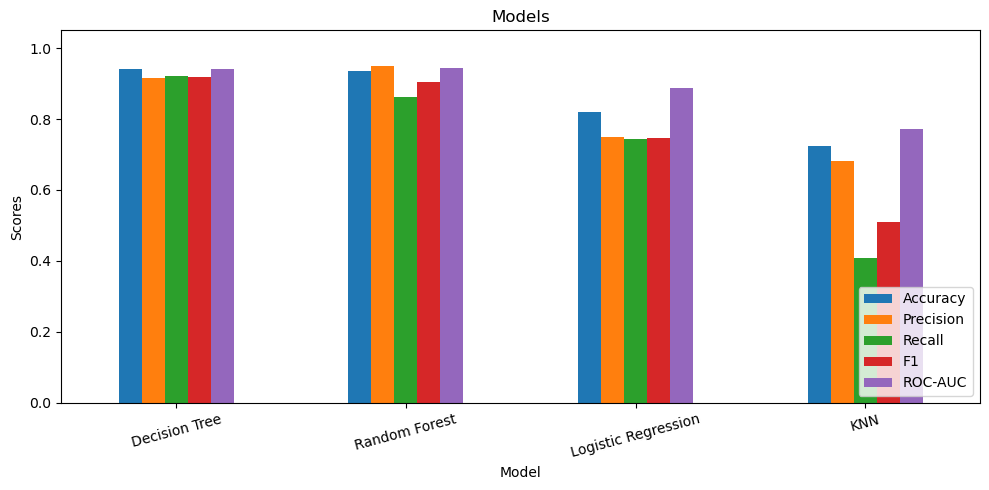

In [47]:
tablo.set_index('Model')[['Accuracy','Precision','Recall','F1','ROC-AUC']].plot(
    kind='bar', figsize=(10,5), rot=15)
plt.title('Models')
plt.ylabel('Scores'); plt.ylim(0,1.05); plt.legend(loc='lower right')
plt.tight_layout(); plt.show()

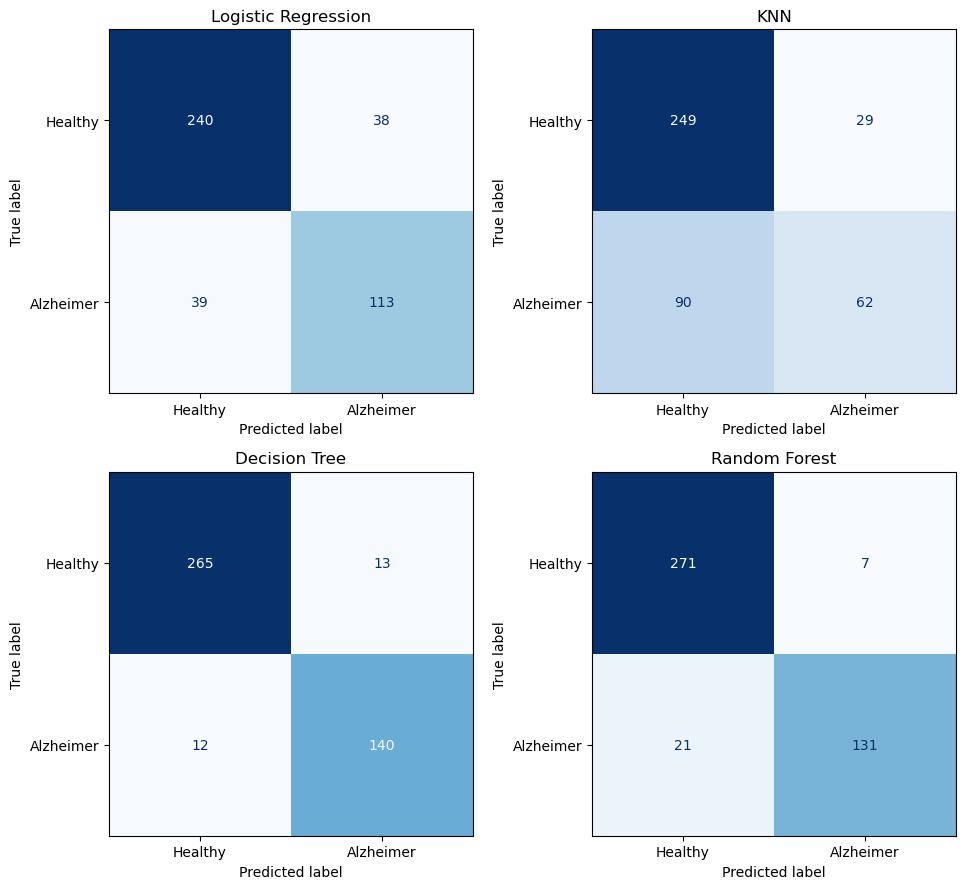

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, (name, gs) in zip(axes.flat, bests.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, gs.predict(X_test), ax=ax, cmap='Blues', colorbar=False,
        display_labels=['Healthy', 'Alzheimer'])
    ax.set_title(name)
plt.tight_layout(); plt.show()

In [52]:
lr = bests['Logistic Regression'].best_estimator_.named_steps['clf']
coefficients = pd.Series(lr.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
print('Influential traits (by coefficient):')
print(coefficients.head(36).round(3))

Influential traits (by coefficient):
FunctionalAssessment        -1.331
ADL                         -1.265
MemoryComplaints             1.136
BehavioralProblems           0.932
MMSE                        -0.863
CholesterolLDL              -0.152
CholesterolHDL               0.149
Age                         -0.139
HeadInjury                  -0.120
Ethnicity_2                  0.111
SleepQuality                -0.107
CholesterolTriglycerides     0.106
Hypertension                 0.095
DifficultyCompletingTasks    0.090
Ethnicity_3                 -0.078
PersonalityChanges          -0.077
CardiovascularDisease        0.075
SystolicBP                  -0.072
EducationLevel              -0.068
FamilyHistoryAlzheimers     -0.063
DiastolicBP                  0.056
Smoking                     -0.056
AlcoholConsumption          -0.048
Confusion                   -0.048
Ethnicity_1                 -0.044
CholesterolTotal             0.041
PhysicalActivity            -0.036
Forgetfulness     

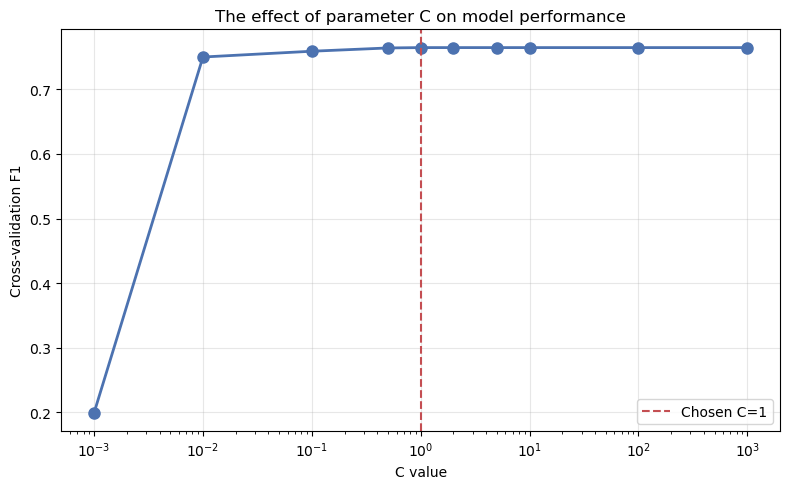

In [54]:
from sklearn.model_selection import cross_val_score

Cs = [0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10, 100, 1000]
cvf1s = []
for C in Cs:
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('clf', LogisticRegression(C=C, max_iter=2000, random_state=42))])
    score = cross_val_score(pipe, X_train, y_train, scoring='f1', cv=cv).mean()
    cvf1s.append(score)

plt.figure(figsize=(8, 5))
plt.plot(Cs, cvf1s, 'o-', color='#4C72B0', lw=2, markersize=8)
plt.xscale('log')                                    
plt.axvline(1, color='#C44E52', ls='--', label='Chosen C=1')
plt.xlabel('C value')
plt.ylabel('Cross-validation F1')
plt.title('The effect of parameter C on model performance')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()

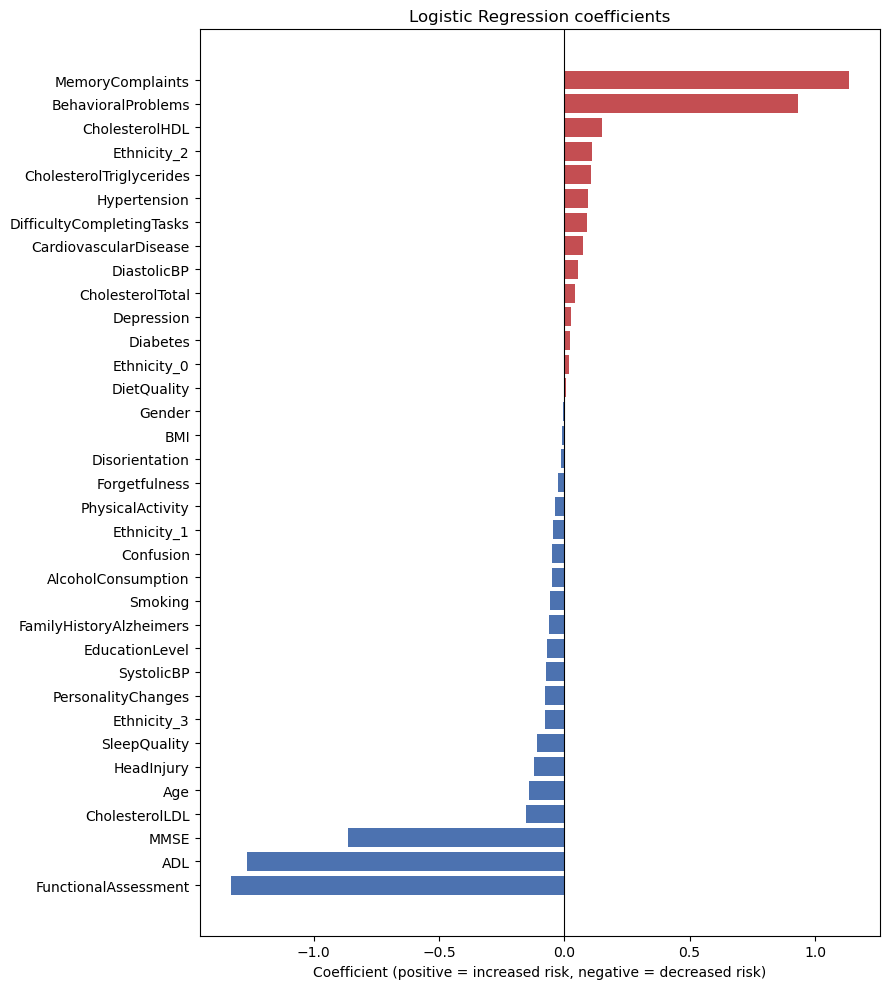

In [57]:
lr = bests['Logistic Regression'].best_estimator_.named_steps['clf']
coefficient = pd.Series(lr.coef_[0], index=X.columns).sort_values()

plt.figure(figsize=(9, 10))
colors = ['#C44E52' if v > 0 else '#4C72B0' for v in coefficient.values]
plt.barh(coefficient.index, coefficient.values, color=colors)
plt.axvline(0, color='black', lw=0.8)
plt.xlabel('Coefficient (positive = increased risk, negative = decreased risk)')
plt.title('Logistic Regression coefficients')
plt.tight_layout()
plt.show()